# Models

In [1]:
import numpy as np
from scipy.stats import gamma, norm
# get truncated gamma and normal distributions
from scipy.stats import truncnorm
# from truncnorm get gamma and normal distributions


class SlopeMAPPerceptual:
    def __init__(self, *args, **kwargs):
        # Leak parameter
        self.leak = kwargs.get('leak', 0)
        # x values = forcefield values
        self.x = kwargs.get('x', np.linspace(-1, 1, 9).round(2))
        if not isinstance(self.x, np.ndarray):
            self.x = np.array(list(self.x))
        
        # Initialize outcome-based prior
        # Slope prior mean and standard deviation
        self.slope_prior_mean = kwargs.get('slope_prior_mean', 0.0)  # Default mean to 0
        self.slope_prior_std = kwargs.get('slope_prior_std', 1.0)    # Default std to 1.0
        
        # Ensure the prior standard deviation is positive
        self.slope_prior_std = max(0.001, self.slope_prior_std)  # Set a minimum value
        
        # Possible values for the slope
        self.slope_range = kwargs.get('slope_range', np.arange(-10, 10, 0.1))
        
        # Initialize log-posterior for the slope with prior
        self.lp_slope = np.log(norm.pdf(self.slope_range, self.slope_prior_mean, self.slope_prior_std))
        
        # Define logit function
        self.logit = lambda x: 1 / (1 + np.exp(x))

        self.binary = kwargs.get('binary', True)
        
    def perceptual_update(self, choice, outcome, spaceship_estimate=None):
        """Update the log-posterior of the slope based on observed data."""
        if self.binary:
            v = self.slope_range * choice
            v = v - v * 2 * outcome  # Switch to negative if forcefield destroyed
    
            # Binary outcome likelihood
            ll = np.log(self.logit(v))
        else:
           # Continuous outcome: outcome = sigmoid(slope * x) * spaceship reward
            logits = self.slope_range * choice

            # logistic probabilities
            p = self.logit(logits)

            # in the generative process of exp. 3, spaceship rewards is
            # multiplied by shield value to produce an outcome
            # Use observed outcome and estimated spaceship to derive implied sigmoid output
            pred_outcomes = np.clip(outcome / spaceship_estimate, 1e-6, 1 - 1e-6)
            # pred_outcomes = p * (spaceship_estimate * 2)

            # gaussian likelihood: compare each pred_outcome to the obtained outcome
            likelihoods = np.exp(-0.5 * ((p-pred_outcomes) ** 2) / 0.1)
            # likelihoods = np.exp(-0.5 * ((outcome - pred_outcomes) ** 2) / 0.2)

            # posterior
            posterior = likelihoods / np.sum(likelihoods)

            ll = np.log(posterior)

        # Update log posterior
        self.lp_slope += ll
           
    def predict_shield_p(self, shields):
        """Predict outcomes (linear or logit) for given forcefields."""
        # Predict for 2 displayed forcefields
        x = np.arange(len(self.x))
        to_select = x[np.isin(self.x, shields)]
        slope = -self.get_slope() * int(self.binary) + self.get_slope() * int(not self.binary)
        return self.logit(slope * self.x[to_select])
    
    def get_slope(self):
        """Compute the current slope as the weighted mean of the slope range."""
        w = np.exp(self.lp_slope - np.max(self.lp_slope))
        slope = np.sum(w * self.slope_range) / np.sum(w)
        return slope


class NormativeValue:
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1):
        """
        Bayesian reward model using Normal-Gamma conjugate prior for multiple spaceships.

        Parameters:
            spaceship_ids : list of spaceship identifiers (ints or strings)
            mu0, kappa0, alpha0, beta0 : prior hyperparameters for all spaceships
        """
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.data = {sid: [] for sid in spaceship_ids}

    def value_update(self, spaceship_id, reward):
        """
        Add an observed reward for a specific spaceship.

        Parameters:
            spaceship_id : ID of the spaceship
            reward : observed scalar reward
        """
        if spaceship_id not in self.data:
            raise ValueError(f"Unknown spaceship ID: {spaceship_id}")
        self.data[spaceship_id].append(reward)

    def compute_posterior(self, spaceship_id):
        """
        Compute the posterior parameters for a given spaceship.
        """
        if self.model == 'perceptual':
            return 
            
        xi = np.array(self.data[spaceship_id])
        n = len(xi)

        if n == 0:
            return self.mu0, self.kappa0, self.alpha0, self.beta0

        x_bar = xi.mean()
        S = np.sum((xi - x_bar) ** 2)

        kappa_n = self.kappa0 + n
        mu_n = (self.kappa0 * self.mu0 + n * x_bar) / kappa_n
        alpha_n = self.alpha0 + n / 2
        beta_n = self.beta0 + 0.5 * S + (self.kappa0 * n * (x_bar - self.mu0) ** 2) / (2 * kappa_n)

        return mu_n, kappa_n, alpha_n, beta_n

    def posterior_predictive_mean(self, spaceship_id):
        """
        Return the expected value (mean) of the predictive distribution for a spaceship.
        """
        if self.model == 'perceptual':
            return 1.0
        mu_n, _, _, _ = self.compute_posterior(spaceship_id)
        return mu_n

    def sample_posterior(self, spaceship_id, n_samples=1000):
        """
        Sample possible mean rewards for a spaceship from the posterior predictive distribution.
        """
        mu_n, kappa_n, alpha_n, beta_n = self.compute_posterior(spaceship_id)

        tau_samples = gamma.rvs(a=alpha_n, scale=1 / beta_n, size=n_samples)
        mu_samples = norm.rvs(loc=mu_n, scale=1 / np.sqrt(kappa_n * tau_samples))
        #truncated normal distribution
        mu_samples = truncnorm.rvs(a=0, b=1, loc=mu_samples, scale=1 / np.sqrt(kappa_n * tau_samples))

        return mu_samples

    def reset(self, spaceship_id=None):
        """
        Reset observations for one or all spaceships.
        """
        if spaceship_id is None:
            for sid in self.data:
                self.data[sid] = []
        else:
            self.data[spaceship_id] = []

class NormativePolicy(NormativeValue):
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1,
                 burn_in=500, samples=1000, model=False, omega=0, beta=1, binary=True):
        NormativeValue.__init__(self, spaceship_ids, mu0, kappa0, alpha0, beta0)
        if model == 'gibbs':
            print('model is gibbs')
            self.perceptual = NormativePerceptual(burn_in=burn_in, samples=samples)
            self.perceptual.model = 'gibbs'
        else:
            # print('model is map')
            self.perceptual = SlopeMAPPerceptual(binary=binary)
            self.perceptual.model = 'map'
        self.perceptual_update = self.perceptual.perceptual_update
        self.predict_shield_p = self.perceptual.predict_shield_p
        
        self.omega = omega
        self.beta = beta
        self.model = model
        self.v_log_ratio_list = []
        self.p_log_ratio_list = []
        self.v_log_ratio = 0
        self.p_log_ratio = 0

    def expected_reward(self, spaceship_id, shield_strength):
        """
        Compute the expected reward for a spaceship given a shield strength z

        Parameters:
            spaceship_id : spaceship ID
            shield_strength : scalar z*

        Returns:
            Expected reward E[Y | z*, Z, B, X]
        """
        # Step 1: compute P(b=1 | z*) from probit model
        p_success = 1.0  # Default if no shield strength is provided
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)

        # Step 2: compute E[μ | X] from reward model
        E_mu = 1.0 
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n

        # Step 3: combine both
        return p_success, E_mu

    def get_spaceship_mean(self, spaceship_id):
        E_mu = 1.0
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n
        return E_mu
    
    def get_shield_probability(self, shield_strength):
        p_success = 1.0
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)
        return p_success

    def choose(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        self.v_log_ratio_list.append(v_lr)  
        self.p_log_ratio_list.append(p_lr)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
    
    def get_likelihood(self, spaceships, shields):
        """
        computes the likelihood of both options
        given the shield strengths and  spaceships
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        # estimated p of choosing option 1
        ep1 = 1/(1 + np.exp(self.beta*-dv))

        return [ep1, 1-ep1]
        
        
    def choose2(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        self.v_log_ratio = np.log(v1) - np.log(v2)
        self.p_log_ratio = np.log(p1) - np.log(p2)

        # # v_lr = v_lr / np.std(self.v_log_ratio_list)
        # # p_lr = p_lr / np.std(self.p_log_ratio_list)

        # dv = (1-self.omega) * v_lr + self.omega * p_lr

        # return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
        
        # # not a dic now but two arrays
        expected_rewards = [
            sid*shield
            for sid, shield in zip([v1, v2], [p1, p2])
        ]
        return np.argmax(expected_rewards)

        #best_id = max(expected_rewards, key=expected_rewards.get)
        


In [2]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/raw/fullpilot1466.csv')
df2 = pd.read_csv('../data/raw/fullpilot13_22.csv')
df3 = pd.read_csv('../data/raw/test/spaceprl(26).csv')

df = df[df.expName.isin(['FullPilot12', 'FullPilot13', 'FullPilot14', ])]
df2 = df2[df2.expName.isin(['FullPilot12', 'FullPilot13'])]
df3 = df3[df3.expName.isin(['FullPilot12_2'])]
#concat df and df3
df = pd.concat([df, df3])

df = df.groupby('prolificID').filter(lambda x: len(x) >= 483)
df2 = df2.groupby('prolificID').filter(lambda x: len(x) >= 483)

df = pd.concat([df, df2])
# df = df.groupby('prolificID').filter(lambda x: len(x) <= 432)
# keep  prolificIDs that are more than 10 characters
df = df[df.prolificID.str.len() > 10]
# show prolificIDs

expName = ['FullPilot12_2',  'FullPilot12', 'FullPilot13', 'FullPilot14']

df['opti_ss'] = ((df.m1 > df.m2) & (df.choice==1)) | ((df.m1 < df.m2) & (df.choice==2))
df['opti_ff'] = ((df.p1 > df.p2) & (df.choice==1)) | ((df.p1 < df.p2) & (df.choice==2))
df['opti_ev'] = ((df.ev1 > df.ev2) & (df.choice==1)) | ((df.ev1 < df.ev2) & (df.choice==2))
df['chosen_p'] = np.where(df.choice == 1, df.p1, df.p2)
df['chosen_m'] = np.where(df.choice == 1, df.m1, df.m2)

df.loc[df.expName=='FullPilot14', 'destroyed'] = 1
df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)



df = df[df.expName.isin(expName)]
print(f'N = {len(df.prolificID.unique())}')

# remove duplicates and only take first based on prolificID, t, session
df = df.drop_duplicates(subset=['prolificID', 't', 'session'])

# replace all of the above by df
# we have m1, m2 and p1, p2, we need to say what option is riskier (higher variance) 
df['var1'] = df.p1 * (df.m1 - df.ev1)**2 + (1 - df.p1) * (0 - df.ev1)**2

df['var2'] = df.p2 * (df.m2 - df.ev2)**2 + (1 - df.p2) * (0 - df.ev2)**2
df['riskier'] = np.where(df.var1 > df.var2, 1, 2)
df['chose_safe'] = np.where(df.choice != df.riskier, 1, 0)
df['chose_risky'] = np.where(df.choice == df.riskier, 1, 0)


df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)
df['outcome'] /= 1000
# fireTime is in ms, convert to seconds
df['fireTime'] = df.fireTime / 1000
# df['trial'] = ((df.t.max()+1) * (df.session-2)) + df.t
df['trial'] = df.t
df['s'] = list(zip(df.m1, df.m2))

print('Number of participants:', df.prolificID.nunique())
map_prolificID = {pid: i for i, pid in enumerate(df.prolificID.unique())}
df['id'] = df.prolificID.map(map_prolificID)

# df['pair'] = df.pair.apply(lambda x: 0 if x < 0 else x)

# define probabilities
x = np.linspace(-1, 1, 9)
pp = (1/(1+np.exp(-2*x))).round(2)


slope = 2
logistic = lambda x: 1/(1+np.exp(-slope*x))
map_ff_values = {logistic(i).round(2):i for i in np.linspace(-1, 1, 9)}
map_ff_values[1] = 1
df['agent'] = df.prolificID

df['s'] = list(zip(df.m1, df.m2))
df['a'] = (df.choice - 1).astype(int)  # Convert choice to 1 or 0
df['r'] = df.outcome
df['ff1'] = df.p1.map(map_ff_values)
df['ff2'] = df.p2.map(map_ff_values)


df['destroy'] = df.destroyed


N = 245
Number of participants: 245


In [3]:
session = 3
df_ = df[(df.session==session)].groupby(['prolificID'], as_index=False).mean(numeric_only=True)

import scipy.stats as stats

df_['delta'] = df_.opti_ff - df_.opti_ss

df_['opti_ff'] = df_.opti_ff.astype(float)
df_['opti_ss'] = df_.opti_ss.astype(float)
df_['delta'] = df_.delta.astype(float)
df['opti_ff'] = df['opti_ff'].astype(float)
df['opti_ss'] = df['opti_ss'].astype(float)
         
df2 = df[(df.session==session)]

def get_group2(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    ttest = stats.ttest_rel(opti_ff, opti_ss)
    p = ttest.pvalue
    t = ttest.statistic
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p > 0.05:
        if p_ss and p_ff:
            return 'balanced'
        if p_ss:
            return 'value'
        if p_ff:
            return 'perceptual'
        return 'random'
    
    if t > 0 and p_ff:
        return 'perceptual'
    if t < 0  and p_ss:
        return 'value'

    return 'random'

def get_group(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p_ss and p_ff:
        return 'combined'
        

    if p_ff:
        return 'perceptual'
    if p_ss:
        return 'value'

    return 'random'
    # raise ValueError('unexpected value')

df_['group'] = df_.apply(get_group, axis=1)

df['group'] = df['prolificID'].map(df_.set_index('prolificID')['group'])

# df = df[df.group != 'random']
print(len(df.prolificID.unique()))

245


In [4]:
import itertools
from scipy.special import logsumexp
from scipy.stats import norm


def fit(x0, *args):
    # print('Running fit...')
    pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, ff_values = args
    try:
        _ = len(x0)
    except:
        x0 = [x0]

    if model  in ('map', 'value', 'perceptual'):
        omega = x0[0]
        beta = x0[1]
        m = NormativePolicy(
            spaceship_ids=[280, 380, 500, 620, 720],
            omega=omega,
            beta=beta,
            binary=exp!='FullPilot14',
        )
    else:
        raise ValueError(f"Unknown model: {model}")
    
    logit = lambda x: 1 / (1 + np.exp(x))

    if model != 'random':

        ll = 0
        for t in range(ntrials):

            ff_chosen = [ff1[t], ff2[t]][a[t]]
            p_chosen = logit(-2*ff_chosen).round(2)

            if session[t] in (1, 3) and ('value' not in model):
                if exp == 'FullPilot14':
                    # spaceship_estimates = np.array([
                    #     m.posterior_predictive_mean(sid)
                    #     for sid in [280, 380, 500, 620, 720]
                    # ])
                    if session[t] == 1:
                        spaceship_estimate = .5
                    else:
                        spaceship_estimate = m.posterior_predictive_mean(s[t][a[t]])
                    m.perceptual_update(ff_chosen, r[t], spaceship_estimate=spaceship_estimate)
                else:
                    m.perceptual_update(ff_chosen, destroy[t])

            if session[t] in (0, 2, 3) and ('perceptual' not in model):
                if destroy[t]:
                    m.value_update(s[t][a[t]], r[t])
                if (not destroy[t]) and (exp == 'FullPilot13'):
                    m.value_update(s[t][a[t]], r[t]/2)

            if session[t] in (3, ) or fit_training:
                p_of_choices = m.get_likelihood(s[t], [ff1[t], ff2[t]])
                ll += np.log(p_of_choices[a[t]] + 1e-10)
    else:
        ll = 0
        for t in range(ntrials):
            ll += np.log(np.exp([.5, .5] - logsumexp([.5, .5])))[0]

    beta_prior_logpdf = norm.logpdf(beta, loc=1e5/2, scale=5)
    # check that beta prior is a valid number
    if np.isnan(beta_prior_logpdf):
        beta_prior_logpdf = 0
    elif np.isinf(beta_prior_logpdf):
        beta_prior_logpdf = 0
    # ll += beta_prior_logpdf

    return -ll,



In [39]:
exp = ['FullPilot12','FullPilot13', 'FullPilot14']
df.expName.unique()


array(['FullPilot14', 'FullPilot12_2', 'FullPilot12', 'FullPilot13'],
      dtype=object)

In [5]:
from joblib import Parallel, delayed
import itertools
from pybads import BADS
import pandas as pd
from tqdm.notebook import tqdm
import numpy as np

# Assuming df is predefined
exp = ['FullPilot12', 'FullPilot12_2', 'FullPilot13', 'FullPilot14']
agents = df[(df.expName.isin(exp))].agent.unique()
models = ['map']
parallel = True 

# Function to optimize for one agent and model
def optimize_agent_model(agent, model, agent_data, fit_training=False, n_starts=1):
    # print('Running optimization for', agent, model)
    df2 = agent_data
    
    # Condition to drop rows
    if not fit_training:
        condition = ~((df2['session'] == 3) & (~df2['pair'].isin([0, 1])))
    else:
        condition = (df2['session'].isin([0, 2]))
    # # # Drop rows meeting the condition, keeping other rows intact
    df2 = df2.loc[condition]

    s, a, r = df2.s.values, df2.a.values, df2.r.values
    ff1, ff2 = df2.ff1.values, df2.ff2.values
    session = df2.session.values
    destroy = df2.destroy.values
    ntrials = df2.shape[0]
    exp = df2.expName.values[0]
    pid = map_prolificID[df2.prolificID.values[0]]

    def target(x):
        return fit(x, *(pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, map_ff_values.values()))[0]

    if any(s in model for s in ['absolute', 'log-ratio', 'absolute-var', 'map', 'perceptual', 'value']):
        lower_bounds = np.array([0, 0])
        upper_bounds = np.array([1, 1e4])
        # Plausible bounds for starting points
        plausible_lower_bounds = np.array([0.05, 1])
        plausible_upper_bounds = np.array([0.95, 50])
    else:
        # Default fallback
        lower_bounds = np.array([0, 0])
        upper_bounds = np.array([1, 1e4])
        plausible_lower_bounds = np.array([0.05, 1])
        plausible_upper_bounds = np.array([0.95, 50])

    # Multi-start optimization
    best_result = None
    
    # Generate random starting points within plausible bounds
    x0_list = [
        np.array([
            np.random.uniform(plausible_lower_bounds[0], plausible_upper_bounds[0]),
            np.random.uniform(plausible_lower_bounds[1], plausible_upper_bounds[1])
        ]) for _ in range(n_starts - 1)
    ]
    
    # Add standard starting point
    # If starting point is 1, then start with [.5, 1]
    standard_x0 = np.array([0.5, 1.0]) if n_starts == 1 else np.array([0.5, 1.0])
    x0_list.append(standard_x0)

    for x0 in x0_list:
        try:
            bads = BADS(
                target,
                x0=x0,
                lower_bounds=lower_bounds,
                upper_bounds=upper_bounds,
                plausible_lower_bounds=plausible_lower_bounds,
                plausible_upper_bounds=plausible_upper_bounds,
                options={'display': 'off'}
            )
            optimize_result = bads.optimize()
            
            if best_result is None or optimize_result.fval < best_result.fval:
                best_result = optimize_result
        except Exception as e:
            # Fallback for optimization errors in specific starts
            continue

    if best_result is None:
        return {'agent': agent, 'model': model, 'omega': np.nan, 'beta': np.nan, 'll': np.inf, 
                'group': df2.group.values[0], 'ntrials': ntrials, 'exp': exp, 'prolificID': df2.prolificID.values[0]}

    return {'agent': agent, 'model': model, 'omega': best_result.x[0], 'beta': best_result.x[1], 
            'll': best_result.fval, 'group': df2.group.values[0], 'ntrials': ntrials, 'exp': exp, 
            'prolificID': df2.prolificID.values[0]}


from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm_joblib import ParallelPbar
import itertools

# Prepare list of all agent-model pairs
tasks = itertools.product(agents, models)


results = []
parallel = True
fit_training = False

if parallel:
    # Parallel execution with notebook-friendly progress bar
    results = []
    for result in ParallelPbar('N sub')(n_jobs=-2, # Use all available cores except 1 to keep the system responsive
                            backend='loky' 
    )(delayed(optimize_agent_model)(agent, model, df[df.agent == agent].sort_values('t'), fit_training) for agent, model in tasks):
        results.append(result)

else:

    # non parallel version
    results = []
    for agent, model in tasks:
        results.append(optimize_agent_model(agent, model, df[df.agent == agent].sort_values('t')))
        # pbar.update()

df_fit = pd.DataFrame(results)

c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


N sub:   0%|          | 0/245 [00:00<?, ?it/s]

KeyboardInterrupt: 

# SIMULATE

In [6]:
# 1. Load fitted parameters and original data
df_fit_original = pd.read_csv('../data/processed/omega_fit_full.csv')
df_fit_original = df_fit_original[df_fit_original.model == 'map']
# Filter out 'random' group if needed, but let's keep all for now to see quality
print(f"Loaded {len(df_fit_original)} fitted agents.")


Loaded 245 fitted agents.


In [21]:
df_fit_original = df_fit[df_fit.model=='map']

In [7]:
# 2. Define simulation function
def simulate_agent_data(agent_data, omega, beta):
    """
    Simulate choices and outcomes for a single agent based on their trial structure and parameters.
    """
    df_sim = agent_data.sort_values(['session', 't']).copy()
    ntrials = len(df_sim)
    exp = df_sim.expName.values[0]
    binary = exp != 'FullPilot14'
    
    # Initialize model
    m = NormativePolicy(
        spaceship_ids=[280, 380, 500, 620, 720],
        omega=omega,
        beta=beta,
        binary=binary
    )
    
    # Data arrays for simulation logic
    s = df_sim.s.values
    ff1 = df_sim.ff1.values
    ff2 = df_sim.ff2.values
    p1 = df_sim.p1.values
    p2 = df_sim.p2.values
    sessions = df_sim.session.values
    outcomes_raw = [df_sim.outcome1.values / 1000, df_sim.outcome2.values / 1000]
    
    sim_choices = []
    sim_outcomes = []
    sim_destroyed = []
    
    for t in range(ntrials):
        # 1. Agent makes a choice
        a = m.choose(s[t], [ff1[t], ff2[t]])
        sim_choices.append(a)
        
        # 2. Determine outcome
        p_success = [p1[t], p2[t]][a]
        r_raw = outcomes_raw[a][t]
        
        if binary:
            # Sample success based on probability p_success
            # Note: In this project's code, 'destroyed=1' means reward was obtained (success)
            destroyed = 1 if np.random.random() < p_success else 0
            outcome = r_raw if destroyed else 0.0
        else:
            # FullPilot14: outcomes are continuous
            destroyed = 1
            outcome = r_raw # Assuming r_raw is already scaled by shield effectiveness
            
        sim_outcomes.append(outcome)
        sim_destroyed.append(destroyed)
        
        # 3. Update model state (same logic as in fit function)
        ff_chosen = [ff1[t], ff2[t]][a]
        
        # Perceptual update (Exp session 1 and 3)
        if sessions[t] in (1, 3):
            if not binary:
                # For FP14, estimate spaceship reward for continuous update
                spaceship_estimate = 0.5 if sessions[t] == 1 else m.posterior_predictive_mean(s[t][a])
                m.perceptual_update(ff_chosen, outcome, spaceship_estimate=spaceship_estimate)
            else:
                m.perceptual_update(ff_chosen, destroyed)

        # Reward/Value update (Exp session 0, 2, 3)
        if sessions[t] in (0, 2, 3):
            if destroyed or not binary:
                m.value_update(s[t][a], outcome)
            if (not destroyed) and (exp == 'FullPilot13'):
                m.value_update(s[t][a], outcome/2)

    # Update dataframe with simulated data
    df_sim['choice'] = np.array(sim_choices) + 1
    df_sim['a'] = sim_choices
    df_sim['r'] = sim_outcomes
    df_sim['outcome'] = sim_outcomes
    df_sim['destroyed'] = sim_destroyed
    df_sim['destroy'] = sim_destroyed
    
    return df_sim


In [8]:
# 3. Execute simulation for all agents
simulated_dfs = []

for _, row in tqdm(df_fit_original.iterrows(), total=len(df_fit_original), desc="Simulating agents"):
    pid = row['prolificID']
    omega = row['omega']
    beta = row['beta']
    
    agent_trials = df[df.prolificID == pid]
    if len(agent_trials) == 0:
        continue
        
    df_sim = simulate_agent_data(agent_trials, omega, beta)
    
    simulated_dfs.append(df_sim)

df_sim_all = pd.concat(simulated_dfs).reset_index(drop=True)
print(f"Simulation complete. Total simulated trials: {len(df_sim_all)}")


Simulating agents:   0%|          | 0/245 [00:00<?, ?it/s]

C:\Users\basil\AppData\Local\Temp\ipykernel_34932\808664277.py:248: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))


Simulation complete. Total simulated trials: 119472


In [9]:
# 4. Refit the simulated data to recover parameters
recovery_agents = df_sim_all.agent.unique()
recovery_tasks = itertools.product(recovery_agents, ['map'])

print("Starting recovery fit (this may take a while)...")

# We use the same optimize_agent_model defined earlier in the notebook
# but we provide the simulated data (df_sim_all)
# We set n_starts=1 to use the custom [0.5, 1.0] starting point as requested
recovery_results = []
parallel = True

if parallel:
    from tqdm_joblib import ParallelPbar
    # Using parallel processing as done in the main fit
    recovery_results = ParallelPbar('Recovery')(n_jobs=-2, backend='loky')(
        delayed(optimize_agent_model)(agent, model, df_sim_all[df_sim_all.agent == agent].sort_values(['session', 't']), False, n_starts=1) 
        for agent, model in recovery_tasks
    )
else:
    for agent, model in tqdm(recovery_tasks, total=len(recovery_agents)):
        res = optimize_agent_model(agent, model, df_sim_all[df_sim_all.agent == agent].sort_values(['session', 't']), False, n_starts=1)
        recovery_results.append(res)

df_recovery = pd.DataFrame(recovery_results)
print("Recovery fit complete.")

Starting recovery fit (this may take a while)...


Recovery:   0%|          | 0/245 [00:00<?, ?it/s]

Recovery fit complete.


Number of agents in recovery comparison: 204


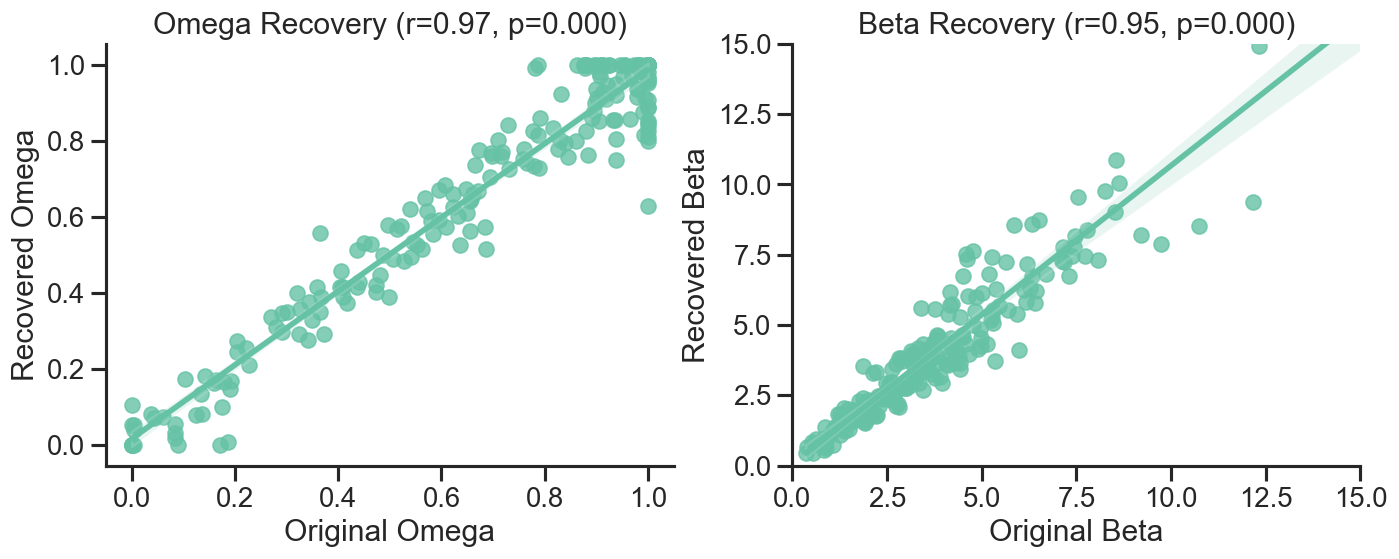

In [50]:
import scipy.stats as stats
# 5. Analyze recovery results
# Merge original and recovered parameters
df_recovery_compare = df_fit_original.merge(
    df_recovery[['agent', 'omega', 'beta']], 
    on='agent', 
    suffixes=('_orig', '_recov')
)
# remove the random group
df_recovery_compare = df_recovery_compare[df_recovery_compare.group != 'random']
print(f"Number of agents in recovery comparison: {len(df_recovery_compare)}")
# Plot recovery for omega and beta
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Omega recovery
sns.regplot(x='omega_orig', y='omega_recov', data=df_recovery_compare, ax=axes[0])
r_omega, p_omega = stats.pearsonr(df_recovery_compare.omega_orig, df_recovery_compare.omega_recov)
axes[0].set_title(f'Omega Recovery (r={r_omega:.2f}, p={p_omega:.3f})')
axes[0].set_xlabel('Original Omega')
axes[0].set_ylabel('Recovered Omega')

# Beta recovery (using log scale often helps for beta)
sns.regplot(x='beta_orig', y='beta_recov', data=df_recovery_compare, ax=axes[1])
plt.xlim(0,15)
plt.ylim(0,15)
r_beta, p_beta = stats.pearsonr(df_recovery_compare.beta_orig, df_recovery_compare.beta_recov)
axes[1].set_title(f'Beta Recovery (r={r_beta:.2f}, p={p_beta:.3f})')
axes[1].set_xlabel('Original Beta')
axes[1].set_ylabel('Recovered Beta')

plt.tight_layout()
sns.despine()
plt.show()


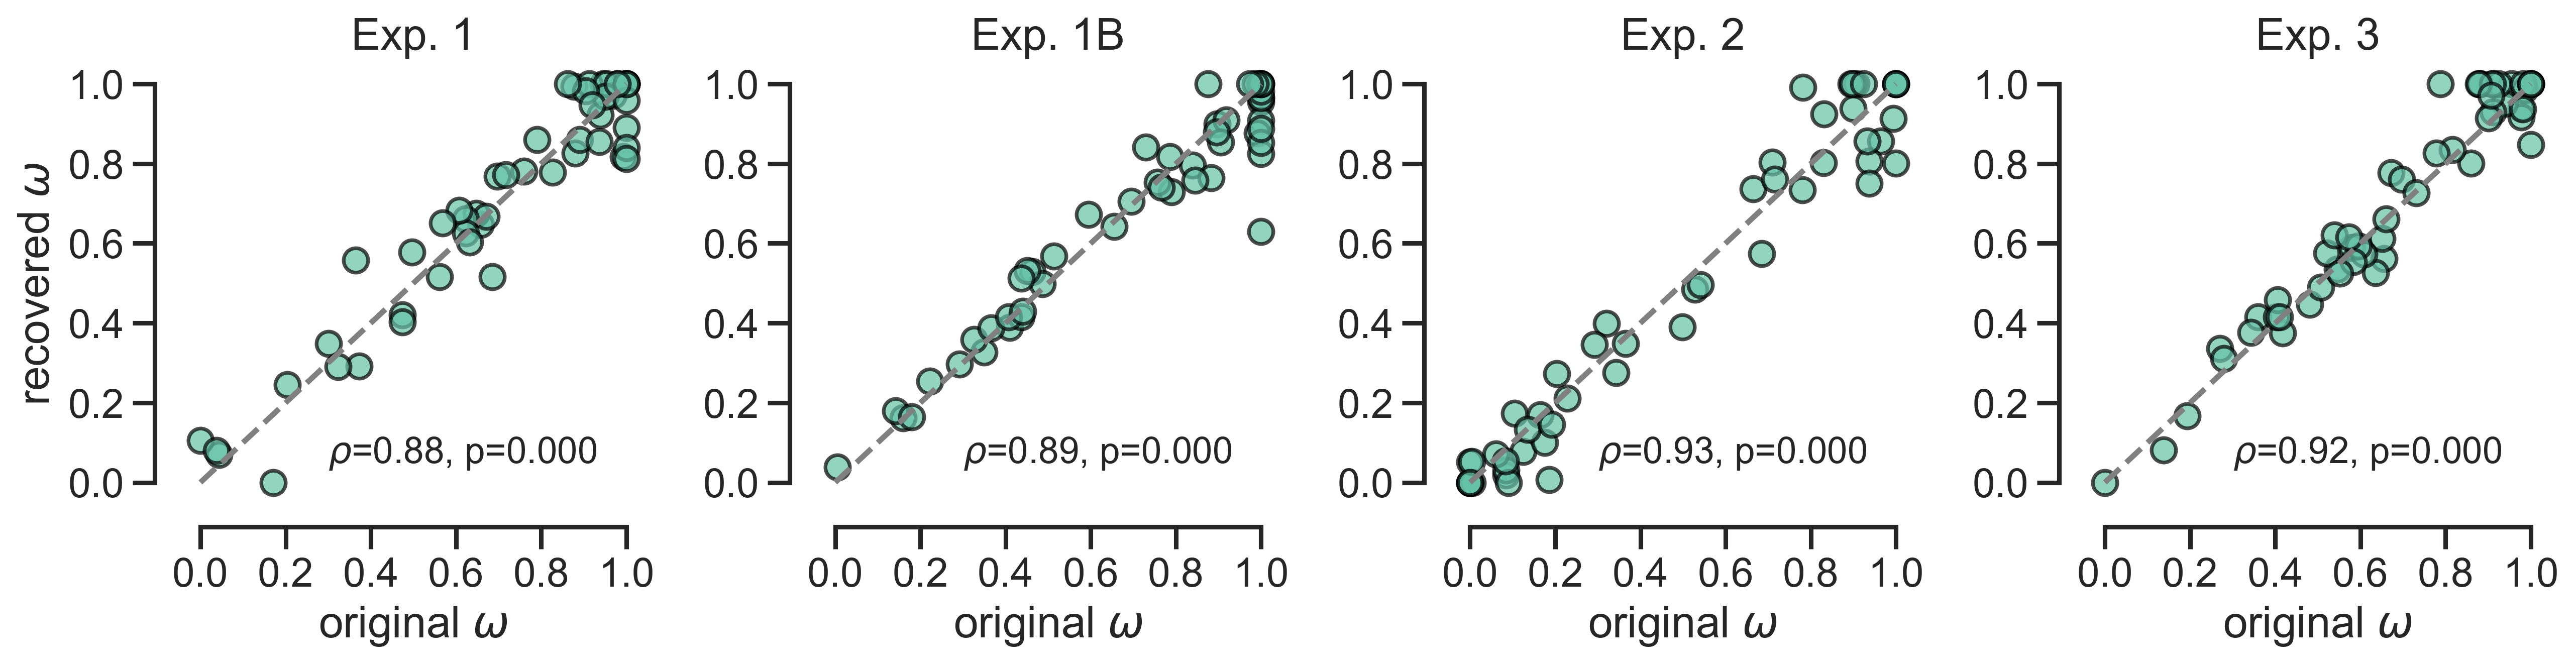

In [121]:
# recovery per experiment
df_recovery_compare['exp'] = df_recovery_compare.agent.apply(lambda x: df[df.prolificID == x].expName.values[0])

plt.figure(figsize=(20*0.75, 5.5*0.75), dpi=350)

sns.set_context('talk')
exp_name = {
        'FullPilot12': 'Exp. 1',
        'FullPilot12_2': 'Exp. 1B',
        'FullPilot13': 'Exp. 2',
        'FullPilot14': 'Exp. 3',
    }
for n, exp_ in enumerate(['FullPilot12', 'FullPilot12_2', 'FullPilot13', 'FullPilot14']):
    df_exp = df_recovery_compare[df_recovery_compare.exp == exp_]

  
    plt.subplot(1, 4, n+1)    
    plt.scatter(df_exp.omega_orig, df_exp.omega_recov, s=100, edgecolor='black', alpha=0.7)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    r_omega, p_omega = stats.spearmanr(df_exp.omega_orig, df_exp.omega_recov)
    plt.title(f'{exp_name[exp_]}')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xticks(np.arange(0, 1.2, 0.2))
    plt.yticks(np.arange(0, 1.2, 0.2))
    # put the rho and p in bottom right corner
    plt.text(0.3, 0.05, f'$\\rho$={r_omega:.2f}, p={p_omega:.3f}', fontsize=15)
    plt.xlabel('original $\\omega$')
    
    plt.ylabel('')
    if n == 0:
        plt.ylabel('recovered $\\omega$')
    sns.despine(trim=True, offset=10)

plt.tight_layout()

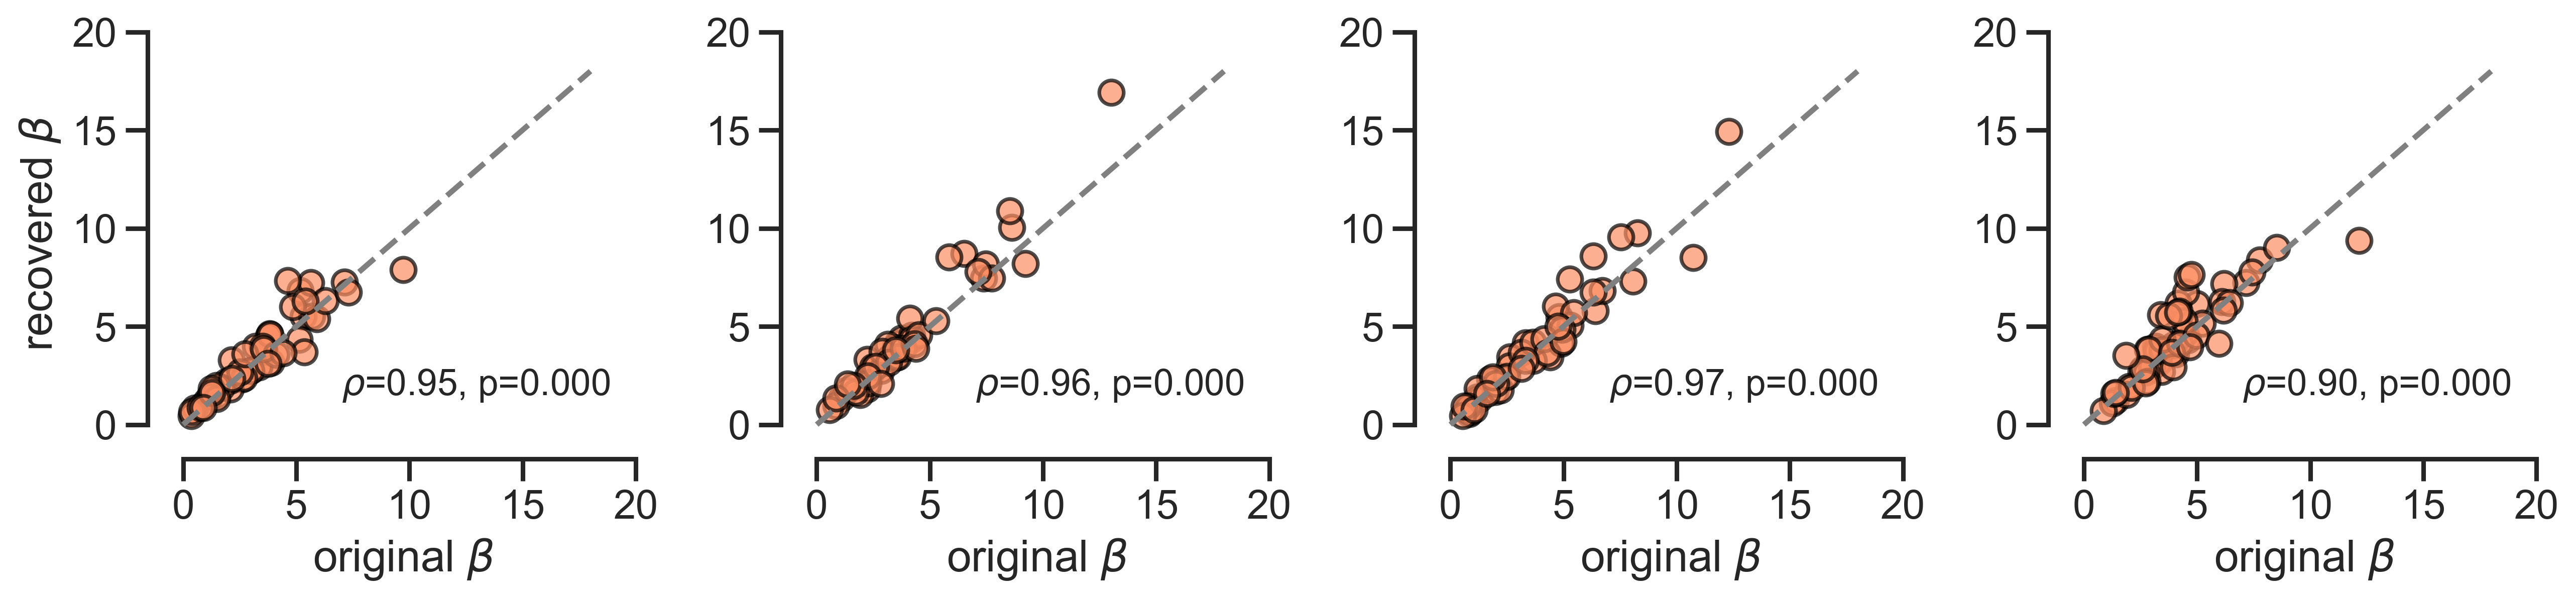

In [122]:
# recovery per experiment
df_recovery_compare['exp'] = df_recovery_compare.agent.apply(lambda x: df[df.prolificID == x].expName.values[0])

plt.figure(figsize=(20*0.75, 5*0.75), dpi=350)
sns.set_context('talk')
max_ = 18
exp_name = {
        'FullPilot12': 'Exp. 1',
        'FullPilot12_2': 'Exp. 1B',
        'FullPilot13': 'Exp. 2',
        'FullPilot14': 'Exp. 3',
    }
for n, exp_ in enumerate(['FullPilot12', 'FullPilot12_2', 'FullPilot13', 'FullPilot14']):
    df_exp = df_recovery_compare[df_recovery_compare.exp == exp_]
    plt.subplot(1, 4, n+1)    
 
    plt.scatter(df_exp.beta_orig, df_exp.beta_recov, s=100, edgecolor='black', alpha=0.7, color='C1')
    plt.plot([0, max_], [0, max_], color='gray', linestyle='--')
    r_beta, p_beta = stats.spearmanr(df_exp.beta_orig, df_exp.beta_recov)
    # plt.title(f'{exp_name[exp_]}')
    plt.xlim(-0.5, max_+2)
    plt.ylim(-0.5, max_+2)
    # y ticks must be step of 5
    plt.yticks(np.arange(0, 25, 5))
    plt.xticks(np.arange(0, 25, 5))
    # put the rho and p in bottom right corner
    plt.text(7, 1.5, f'$\\rho$={r_beta:.2f}, p={p_beta:.3f}', fontsize=15)
    plt.xlabel('original $\\beta$')
    plt.ylabel('')
    if n == 0:
        plt.ylabel('recovered $\\beta$')
    sns.despine(trim=True, offset=10)

# adjust and fit whitespace
plt.tight_layout()